<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 4  :

using numpy array and euler's method

Two stars are moving around their common centre of mass under mutual gravitational force. One star has mass 1.989E30 kg and the other star has mass 1.193E30 kg. The distance between them is 1.496E10 m. Their orbits have eccentricity of 0.40. When the orbit is elliptical with eccentricity e, the speed of the object at closest approach is sqrt((1+e)/(1-e)) times the speed if orbits were circular.
The major axis of the orbits are along X axis.
Simulate the motion of binary system in XY plane of orbit.
Draw the velocity curve for any one star along X direction and along Y direction.

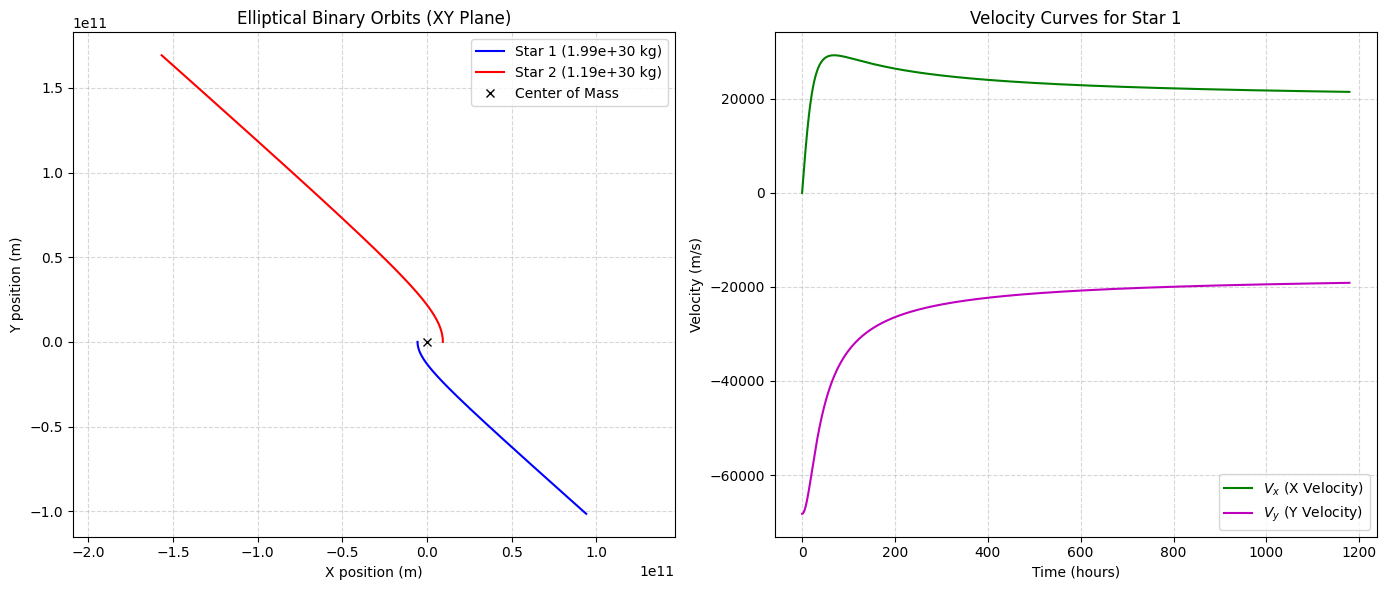

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Constants and Initial Conditions ---
G = 6.67430e-11  # Gravitational constant (m^3 kg^-1 s^-2)

# Masses of the stars
m1 = 1.989e30    # kg
m2 = 1.193e30    # kg
total_mass = m1 + m2

# Geometry and Eccentricity
r_periastron = 1.496e10  # Initial closest distance (m)
e = 0.40                 # Eccentricity

# Positions relative to Center of Mass (COM) along X-axis
x1 = -(m2 / total_mass) * r_periastron
x2 = (m1 / total_mass) * r_periastron

pos1 = np.array([x1, 0.0])
pos2 = np.array([x2, 0.0])

# Velocities at periastron (perpendicular to X-axis, along Y)
v_circular = np.sqrt((G * total_mass) / r_periastron)
v_relative = v_circular * np.sqrt((1 + e) / (1 - e))

vy1 = -(m2 / total_mass) * v_relative
vy2 = (m1 / total_mass) * v_relative

vel1 = np.array([0.0, vy1])
vel2 = np.array([0.0, vy2])

# --- 2. Simulation Parameters ---
# Approximate an orbital period using Kepler's 3rd Law for a semi-major axis 'a'
# a = r_periastron / (1 - e)
a = r_periastron / (1.0 - e)
estimated_period = 2 * np.pi * np.sqrt(a**3 / (G * total_mass))

dt = 100  # Time step in seconds (small enough for Euler stability over a few periods)
num_steps = int((2.5 * estimated_period) / dt)  # Simulate ~2.5 orbits

# Arrays to store tracking data
time_arr = np.zeros(num_steps)
pos1_history = np.zeros((num_steps, 2))
pos2_history = np.zeros((num_steps, 2))
vel1_history = np.zeros((num_steps, 2))

# --- 3. Numerical Integration (Euler's Method) ---
for i in range(num_steps):
    # Store history
    time_arr[i] = i * dt
    pos1_history[i] = pos1
    pos2_history[i] = pos2
    vel1_history[i] = vel1

    # Vector from Star 1 to Star 2
    r_vec = pos2 - pos1
    r_mag = np.linalg.norm(r_vec)

    # Accelerations
    acc1 = (G * m2 / r_mag**3) * r_vec
    acc2 = -(G * m1 / r_mag**3) * r_vec

    # Euler Update Step
    vel1 += acc1 * dt
    vel2 += acc2 * dt

    pos1 += vel1 * dt
    pos2 += vel2 * dt

# --- 4. Plotting Results ---
plt.figure(figsize=(14, 6))

# Plot 1: XY Orbits of Both Stars
plt.subplot(1, 2, 1)
plt.plot(pos1_history[:, 0], pos1_history[:, 1], 'b-', label=f'Star 1 ({m1:.2e} kg)')
plt.plot(pos2_history[:, 0], pos2_history[:, 1], 'r-', label=f'Star 2 ({m2:.2e} kg)')
plt.plot(0, 0, 'kx', label='Center of Mass')
plt.title('Elliptical Binary Orbits (XY Plane)')
plt.xlabel('X position (m)')
plt.ylabel('Y position (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.legend()

# Plot 2: Velocity Curve for Star 1
plt.subplot(1, 2, 2)
plt.plot(time_arr / 3600, vel1_history[:, 0], 'g-', label='$V_x$ (X Velocity)')
plt.plot(time_arr / 3600, vel1_history[:, 1], 'm-', label='$V_y$ (Y Velocity)')
plt.title('Velocity Curves for Star 1')
plt.xlabel('Time (hours)')
plt.ylabel('Velocity (m/s)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()